In [1]:
import pandas as pd
import tensorflow as tf

2022-06-14 20:21:20.852593: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-14 20:21:20.852679: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
from sklearn import datasets

In [3]:
cancer = datasets.load_breast_cancer()
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [4]:
df = pd.DataFrame(data = cancer.data, columns=cancer.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
df.shape

(569, 30)

In [6]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [7]:
y= cancer.target

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [9]:
y.shape

(569,)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(df,y, test_size=0.2,stratify=y)

In [12]:
X_train.shape

(455, 30)

In [14]:
X_test

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
132,16.160,21.54,106.20,809.8,0.10080,0.12840,0.104300,0.05613,0.2160,0.05891,...,19.470,31.68,129.70,1175.0,0.1395,0.30550,0.29920,0.13120,0.3480,0.07619
538,7.729,25.49,47.98,178.8,0.08098,0.04878,0.000000,0.00000,0.1870,0.07285,...,9.077,30.92,57.17,248.0,0.1256,0.08340,0.00000,0.00000,0.3058,0.09938
483,13.700,17.64,87.76,571.1,0.09950,0.07957,0.045480,0.03160,0.1732,0.06088,...,14.960,23.53,95.78,686.5,0.1199,0.13460,0.17420,0.09077,0.2518,0.06960
107,12.360,18.54,79.01,466.7,0.08477,0.06815,0.026430,0.01921,0.1602,0.06066,...,13.290,27.49,85.56,544.1,0.1184,0.19630,0.19370,0.08442,0.2983,0.07185
226,10.440,15.46,66.62,329.6,0.10530,0.07722,0.006643,0.01216,0.1788,0.06450,...,11.520,19.80,73.47,395.4,0.1341,0.11530,0.02639,0.04464,0.2615,0.08269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.023790,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.1499,0.13980,0.11250,0.06136,0.3409,0.08147
520,9.295,13.90,59.96,257.8,0.13710,0.12250,0.033320,0.02421,0.2197,0.07696,...,10.570,17.84,67.84,326.6,0.1850,0.20970,0.09996,0.07262,0.3681,0.08982
331,12.980,19.35,84.52,514.0,0.09579,0.11250,0.071070,0.02950,0.1761,0.06540,...,14.420,21.95,99.21,634.3,0.1288,0.32530,0.34390,0.09858,0.3596,0.09166
404,12.340,14.95,78.29,469.1,0.08682,0.04571,0.021090,0.02054,0.1571,0.05708,...,13.180,16.85,84.11,533.1,0.1048,0.06744,0.04921,0.04793,0.2298,0.05974


In [15]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
X_train = X_train.reshape(455,30,1)
X_test = X_test.reshape(114,30,1)

In [18]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv1D(filters = 32, kernel_size  = 2, input_shape =(30,1), activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Conv1D(filters = 64, kernel_size = 2, activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation = 'relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1,activation = 'sigmoid'))


In [19]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 29, 32)            96        
                                                                 
 batch_normalization (BatchN  (None, 29, 32)           128       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 29, 32)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 28, 64)            4160      
                                                                 
 batch_normalization_1 (Batc  (None, 28, 64)           256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 28, 64)           

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(lr = 0.0005),loss = 'binary_crossentropy', metrics=['accuracy'] )

In [42]:
model.fit(X_train, y_train, epochs=50,validation_data=(X_test,y_test), verbose=1,batch_size =8)

Epoch 1/50
57/57 [==============================] - 1s 15ms/step - loss: 0.1676 - accuracy: 0.9319 - val_loss: 0.0904 - val_accuracy: 0.9649
Epoch 2/50
57/57 [==============================] - 1s 13ms/step - loss: 0.1277 - accuracy: 0.9473 - val_loss: 0.0714 - val_accuracy: 0.9737
Epoch 3/50
57/57 [==============================] - 1s 13ms/step - loss: 0.1189 - accuracy: 0.9560 - val_loss: 0.0361 - val_accuracy: 0.9825
Epoch 4/50
57/57 [==============================] - 1s 13ms/step - loss: 0.0968 - accuracy: 0.9648 - val_loss: 0.0256 - val_accuracy: 1.0000
Epoch 5/50
57/57 [==============================] - 1s 12ms/step - loss: 0.1078 - accuracy: 0.9626 - val_loss: 0.0305 - val_accuracy: 0.9912
Epoch 6/50
57/57 [==============================] - 1s 13ms/step - loss: 0.0908 - accuracy: 0.9560 - val_loss: 0.0363 - val_accuracy: 0.9825
Epoch 7/50
57/57 [==============================] - 1s 13ms/step - loss: 0.1244 - accuracy: 0.9407 - val_loss: 0.0489 - val_accuracy: 0.9912
Epoch 8/50
57

In [43]:
model.history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [44]:
model.history.history['accuracy']

[0.9318681359291077,
 0.9472527503967285,
 0.9560439586639404,
 0.9648351669311523,
 0.9626373648643494,
 0.9560439586639404,
 0.9406593441963196,
 0.9494505524635315,
 0.9648351669311523,
 0.9494505524635315,
 0.9604395627975464,
 0.9714285731315613,
 0.9648351669311523,
 0.9802197813987732,
 0.9648351669311523,
 0.9780219793319702,
 0.9560439586639404,
 0.9692307710647583,
 0.9604395627975464,
 0.9758241772651672,
 0.9626373648643494,
 0.9670329689979553,
 0.9626373648643494,
 0.9758241772651672,
 0.9670329689979553,
 0.9736263751983643,
 0.9758241772651672,
 0.9736263751983643,
 0.9626373648643494,
 0.9670329689979553,
 0.9714285731315613,
 0.9692307710647583,
 0.9912087917327881,
 0.9692307710647583,
 0.9670329689979553,
 0.9670329689979553,
 0.9714285731315613,
 0.9714285731315613,
 0.9648351669311523,
 0.9692307710647583,
 0.9736263751983643,
 0.9824175834655762,
 0.9824175834655762,
 0.9736263751983643,
 0.9758241772651672,
 0.9758241772651672,
 0.9736263751983643,
 0.9780219793

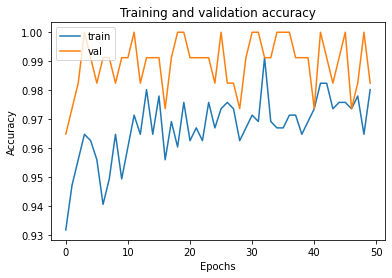

In [45]:
import numpy as np
epochs = np.arange(50)
import matplotlib.pyplot as plt
plt.plot(epochs, model.history.history['accuracy'])
plt.plot(epochs, model.history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'], loc = 'upper left')
plt.title("Training and validation accuracy")
plt.show()

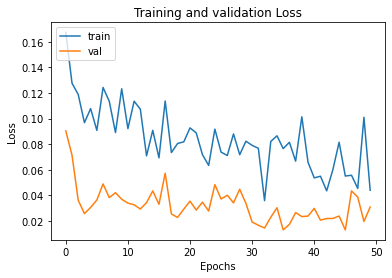

In [46]:
plt.plot(epochs, model.history.history['loss'])
plt.plot(epochs, model.history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'], loc = 'upper left')
plt.title("Training and validation Loss")
plt.show()